In [1]:
%load_ext line_profiler

In [2]:
from rabtracks import *
sns.set_context("paper")
BASINS = ['NA', 'EP', 'NI', 'SI', 'SP', 'WP']

In [3]:
data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}

/tmp/ipykernel_2166/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}
/tmp/ipykernel_2166/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}


In [4]:
def compute_HR(eib, s):
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(~eib_s.lon.isnull(),))
    years_s = np.unique(eib_s.time.dt.year)
    eib_ib_years = clean(eib.where(eib.time.dt.year.isin(years_s),))
    N_ib = len(np.unique(eib_ib_years.track_id))
    N_s = len(np.unique(eib_s.track_id))
    return np.round(N_s/N_ib * 100)

In [5]:
# Hit rate for each source
df = pd.DataFrame()
for b in BASINS:
    print(b)
    eib = data[b]
    for i, s in tqdm(enumerate(eib.source)):
        if s != "IBTrACS":
            HR = compute_HR(eib, s)
            df = pd.concat([df, pd.DataFrame(dict(basin = [b], source = [s.values], HR = [HR]))])

df = df.assign(source = df.source.astype(str))

NA


9it [00:05,  1.62it/s]


EP


9it [00:08,  1.10it/s]


NI


...

9it [00:08,  1.10it/s]


SP


9it [00:04,  1.89it/s]


WP


9it [00:09,  1.06s/it]


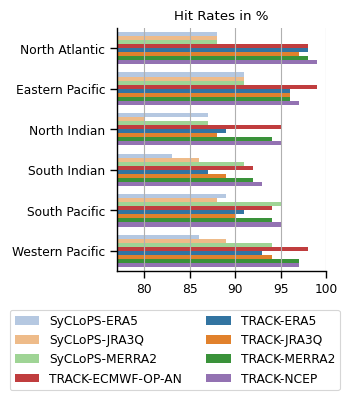

In [6]:
basin_names = {
    "NA": "North Atlantic",
    "EP": "Eastern Pacific",
    "WP": "Western Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "South Pacific",
    "SA": "South Atlantic",
}
df["basin_full"] = df["basin"].map(basin_names)

fig = plt.figure(figsize=cm2inch([9, 8]))
ax = sns.barplot(data=df,
                 y="basin_full", hue="source", x="HR",
                 palette=PALETTE, orient="h")
plt.title("Hit Rates in %")
plt.xlim(77, 100)
plt.grid(axis='x')
ax.get_legend().remove()
fig.legend(ncol=2, loc="outside upper center",
           bbox_to_anchor=(0.5, 0.02), frameon=True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates.png", bbox_inches="tight")
plt.savefig("hit_rates.pdf", bbox_inches="tight")

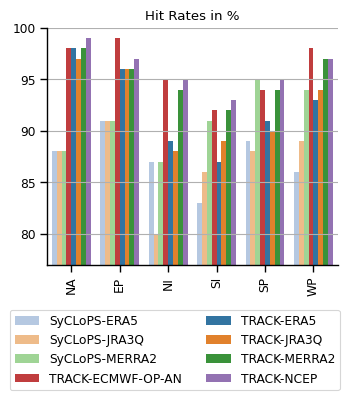

In [7]:
fig = plt.figure(figsize = cm2inch([9,8]))
ax = sns.barplot(data = df, 
            x = "basin", hue = "source", y = "HR", 
            palette = PALETTE,)
plt.xticks(rotation=90)
plt.title("Hit Rates in %")
plt.ylim(77,100)
plt.grid(axis = 'y')
ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.02), frameon = True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

#plt.savefig("hit_rates.png", bbox_inches = "tight")

In [8]:
df.groupby("basin").HR.mean()

basin
EP    94.625
NA    94.250
NI    89.375
SI    89.125
SP    92.000
WP    93.500
Name: HR, dtype: float64

In [9]:
df.groupby("source").HR.mean()

source
SyCLoPS-ERA5         87.333333
SyCLoPS-JRA3Q        87.000000
SyCLoPS-MERRA2       91.000000
TRACK-ECMWF-OP-AN    96.000000
TRACK-ERA5           92.333333
TRACK-JRA3Q          92.333333
TRACK-MERRA2         95.166667
TRACK-NCEP           96.000000
Name: HR, dtype: float64

In [10]:
df["tracker"] = df.source.str.split('-', expand = True).iloc[:,0]

In [11]:
df["RA"] = df.source.str.split('-', expand = True).iloc[:,1]

In [12]:
df.RA.unique()

array(['ERA5', 'JRA3Q', 'MERRA2', 'ECMWF', 'NCEP'], dtype=object)

In [13]:
df[df.RA.isin(['ERA5', 'JRA3Q', 'MERRA2',])].groupby("tracker").HR.mean()

tracker
SyCLoPS    88.444444
TRACK      93.277778
Name: HR, dtype: float64

In [14]:
# Compute only for cat 1+ cyclones
def compute_HR_intense(eib, s):
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(eib_s.wmo_wind >= 32,))
    eib_s = clean(eib_s.where(~eib_s.lon.isnull(),))
    years_s = np.unique(eib_s.time.dt.year)
    eib_ib_years = clean(eib.where(eib.time.dt.year.isin(years_s),))
    eib_ib_years = clean(eib_ib_years.where(eib_ib_years.wmo_wind >= 32,))
    N_ib = len(np.unique(eib_ib_years.track_id))
    N_s = len(np.unique(eib_s.track_id))
    return np.round(N_s/N_ib * 100)

In [15]:
# Hit rate for each source
df_intense = pd.DataFrame()
for b in BASINS:
    print(b)
    eib = data[b]
    for i, s in tqdm(enumerate(eib.source)):
        if s != "IBTrACS":
            HR = compute_HR_intense(eib, s)
            df_intense = pd.concat([df_intense, pd.DataFrame(dict(basin = [b], source = [s.values], HR = [HR]))])

df_intense = df_intense.assign(source = df_intense.source.astype(str))

NA


9it [00:04,  1.87it/s]


EP


9it [00:07,  1.25it/s]


NI


...

9it [00:06,  1.32it/s]


SP


9it [00:03,  2.52it/s]


WP


9it [00:10,  1.17s/it]


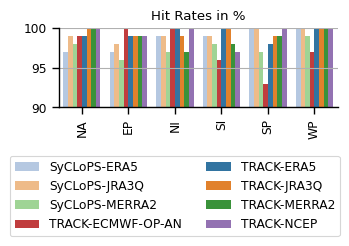

In [16]:
fig = plt.figure(figsize = cm2inch([9,4]))
ax = sns.barplot(data = df_intense, 
            x = "basin", hue = "source", y = "HR", 
            palette = PALETTE,)
plt.xticks(rotation=90)
plt.title("Hit Rates in %")
plt.ylim(90,100)
plt.grid(axis = 'y')
ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.02), frameon = True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates_intense.png", bbox_inches = "tight")
plt.savefig("hit_rates_intense.pdf", bbox_inches = "tight")

In [17]:
df_intense.HR.describe()

count     48.000000
mean      98.729167
std        1.469398
min       93.000000
25%       98.000000
50%       99.000000
75%      100.000000
max      100.000000
Name: HR, dtype: float64

In [18]:
# Only on common period
def compute_HR(eib, s):
    eib = clean(eib.where((eib.time.dt.year >= 2006) & (eib.time.dt.year <= 2022)))
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(~eib_s.lon.isnull(),))
    #years_s = np.unique(eib_s.time.dt.year)
    #eib_ib_years = clean(eib.where(eib.time.dt.year.isin(years_s),))
    N_ib = len(np.unique(eib.track_id))
    N_s = len(np.unique(eib_s.track_id))
    return np.round(N_s/N_ib * 100)

In [19]:
# Hit rate for each source only on common period
df_common = pd.DataFrame()
for b in BASINS:
    print(b)
    eib = data[b]
    for i, s in tqdm(enumerate(eib.source)):
        if s != "IBTrACS":
            HR = compute_HR(eib, s)
            df_common = pd.concat([df_common, pd.DataFrame(dict(basin = [b], source = [s.values], HR = [HR]))])

df_common = df_common.assign(source = df_common.source.astype(str))
df_common = df_common.set_index(["basin", "source"]).join(df.set_index(["basin", "source"]), lsuffix = "_common")

NA


9it [00:02,  3.63it/s]


EP


9it [00:03,  2.43it/s]


NI


...

9it [00:04,  2.25it/s]


SP


9it [00:01,  4.89it/s]


WP


9it [00:06,  1.42it/s]


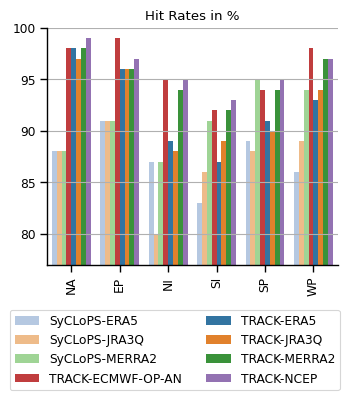

In [20]:
fig = plt.figure(figsize = cm2inch([9,8]))
ax = sns.barplot(data = df_common, 
            x = "basin", hue = "source", y = "HR", 
            palette = PALETTE,)
plt.xticks(rotation=90)
plt.title("Hit Rates in %")
plt.ylim(77,100)
plt.grid(axis = 'y')
ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.02), frameon = True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates_2006_2022.png", bbox_inches = "tight")

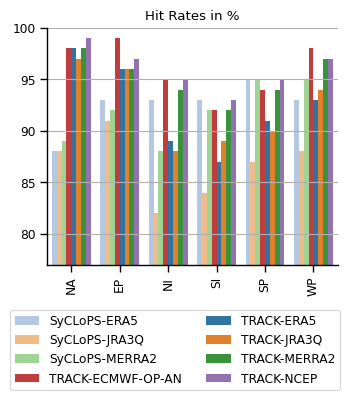

In [13]:
fig = plt.figure(figsize = cm2inch([9,8]))
ax = sns.barplot(data = df_common, 
            x = "basin", hue = "source", y = "HR", 
            palette = PALETTE,)
plt.xticks(rotation=90)
plt.title("Hit Rates in %")
plt.ylim(77,100)
plt.grid(axis = 'y')
ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.02), frameon = True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates_2006_2022.png", bbox_inches = "tight")

In [14]:
df_common[["HR", "HR_common"]].describe()

,HR,HR_common
count,48.000000,48.000000
mean,92.854167,97.270833
std,4.015871,2.247832
min,82.000000,90.000000
25%,89.750000,96.000000
50%,93.000000,98.000000
75%,96.000000,99.000000
max,99.000000,100.000000


In [15]:
df_common.groupby("basin")[["HR", "HR_common"]].mean()

,HR,HR_common
basin,,
EP,95.000,97.750
NA,94.375,97.875
NI,90.500,95.250
SI,90.250,97.125
SP,92.625,97.375
WP,94.375,98.250


In [16]:
df_common[df_common.RA.isin(['ERA5', 'JRA3Q', 'MERRA2',])].groupby("tracker")[["HR", "HR_common"]].mean()

AttributeError: 'DataFrame' object has no attribute 'RA'

In [ ]:
# Mix between common & available
def compute_HR(eib, s):
    eib = clean(eib.where((eib.time.dt.year >= 1980) & (eib.time.dt.year <= 2022)))
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(~eib_s.lon.isnull(),))
    years_s = np.unique(eib_s.time.dt.year)
    eib_ib_years = clean(eib.where(eib.time.dt.year.isin(years_s),))
    N_ib = len(np.unique(eib_ib_years.track_id))
    N_s = len(np.unique(eib_s.track_id))
    return np.round(N_s/N_ib * 100)

In [ ]:
# Hit rate for each source only on common period
df_common = pd.DataFrame()
for b in BASINS:
    print(b)
    eib = data[b]
    for i, s in tqdm(enumerate(eib.source)):
        if s != "IBTrACS":
            HR = compute_HR(eib, s)
            df_common = pd.concat([df_common, pd.DataFrame(dict(basin = [b], source = [s.values], HR = [HR]))])

df_common = df_common.assign(source = df_common.source.astype(str))
df_common = df_common.set_index(["basin", "source"]).join(df.set_index(["basin", "source"]), lsuffix = "_common")

In [ ]:
fig = plt.figure(figsize = cm2inch([9,8]))
ax = sns.barplot(data = df_common, 
            x = "basin", hue = "source", y = "HR", 
            palette = PALETTE,)
plt.xticks(rotation=90)
plt.title("Hit Rates in %")
plt.ylim(77,100)
plt.grid(axis = 'y')
ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.02), frameon = True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates_1980_2022.png", bbox_inches = "tight")

In [ ]:
df_common[["HR", "HR_common"]].describe()

In [ ]:
df_common["diff"] = df_common.HR_common - df_common.HR

In [ ]:
df_common[df_common.RA.isin(["ERA5", "JRA3Q"])]

In [ ]:
df_common[df_common.RA.isin(['ERA5', 'JRA3Q', 'MERRA2',])].groupby("tracker")[["HR", "HR_common"]].mean()